In [1]:
import os
import pandas as pd

# Set dataset path
DATASET_PATH = "/kaggle/input/datasets/alonhaviv/the-maestro-dataset-v3-0-0/maestro-v3.0.0"

if not os.path.isdir(DATASET_PATH):
    raise FileNotFoundError(
        f"DATASET_PATH does not exist: {DATASET_PATH}. Update this path."
    )

print("Dataset path verified")

print("=== TOP LEVEL FILES ===")
top_files = os.listdir(DATASET_PATH)
print(top_files)

print("=== FIND METADATA FILE ===")
csv_path = None
for f in top_files:
    if f.endswith(".csv"):
        csv_path = os.path.join(DATASET_PATH, f)
        print("Found CSV:", csv_path)
        break

if csv_path is None:
    raise FileNotFoundError("No metadata CSV file found.")

print("=== LOAD METADATA ===")
df = pd.read_csv(csv_path)
print("Columns:")
print(df.columns)
print("Rows:", len(df))

Dataset path verified
=== TOP LEVEL FILES ===
['2017', '2011', '2004', 'LICENSE', 'maestro-v3.0.0.csv', 'README', '2006', 'maestro-v3.0.0.json', '2014', '2013', '2009', '2015', '2008', '2018']
=== FIND METADATA FILE ===
Found CSV: /kaggle/input/datasets/alonhaviv/the-maestro-dataset-v3-0-0/maestro-v3.0.0/maestro-v3.0.0.csv
=== LOAD METADATA ===
Columns:
Index(['canonical_composer', 'canonical_title', 'split', 'year',
       'midi_filename', 'audio_filename', 'duration'],
      dtype='object')
Rows: 1276


In [2]:
# Run once if needed
%pip install -q tensorflow pretty_midi matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 17.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pretty_midi
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Pipeline settings
TIMESTEPS = 128 # 128 time steps covers 8 seconds of music at fs=16
FS = 16
N_FEATURES = 88 # 88 piano keys
LATENT_DIM = 64
LSTM_UNITS = 256
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 0.001
MAX_TRAIN = 1200
MAX_VAL = 200
MAX_TEST = 200

OUTPUT_DIR = "generated_midi_lstm_ae"
os.makedirs(OUTPUT_DIR, exist_ok=True)

if "df" not in globals() or "DATASET_PATH" not in globals():
    raise RuntimeError("Run the dataset cell first so df and DATASET_PATH are available.")

print("TensorFlow version:", tf.__version__)
print("Rows in metadata:", len(df))
print("Output directory:", os.path.abspath(OUTPUT_DIR))

2026-05-08 00:24:10.706278: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778199850.893448      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778199850.954597      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778199851.404510      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778199851.404551      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778199851.404554      22 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
Rows in metadata: 1276
Output directory: /kaggle/working/generated_midi_lstm_ae


In [4]:
def midi_to_windows(midi_path, timesteps=TIMESTEPS, fs=FS):
    try:
        midi_obj = pretty_midi.PrettyMIDI(midi_path)
        # Get piano roll, shape is (128, T)
        roll = midi_obj.get_piano_roll(fs=fs)
        # Slice pitch rows 21 through 108 (88 keys)
        roll = roll[21:109, :]
        # Binarize and transpose to (T, 88)
        roll = (roll > 0).astype(np.float32).T
    except Exception:
        return []

    if roll.shape[0] < timesteps:
        return []

    windows = []
    # Segment into windows of length `timesteps`
    for start in range(0, roll.shape[0] - timesteps + 1, timesteps):
        window = roll[start:start + timesteps, :]
        # Filter sparse windows: discard if < 2% of cells are active
        if np.mean(window) >= 0.02:
            windows.append(window)

    return windows

def build_split_array(split_df, max_items):
    sequences = []
    paths = []
    for rel_path in split_df["midi_filename"].tolist()[:max_items]:
        full_path = os.path.join(DATASET_PATH, rel_path)
        if not os.path.exists(full_path):
            continue
        windows = midi_to_windows(full_path)
        for w in windows:
            sequences.append(w)
            paths.append(full_path)

    if not sequences:
        raise RuntimeError("No valid MIDI sequences found for this split.")

    return np.stack(sequences, axis=0), paths

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df = df[df["split"].isin(["validation", "val"])].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)

X_train, train_paths = build_split_array(train_df, MAX_TRAIN)
X_val, val_paths = build_split_array(val_df, MAX_VAL) if len(val_df) > 0 else (None, [])
X_test, test_paths = build_split_array(test_df, MAX_TEST)

if X_val is None:
    split_idx = int(0.9 * len(X_train))
    X_train, X_val = X_train[:split_idx], X_train[split_idx:]

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

# Create tf.data.Datasets
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, X_train)).shuffle(len(X_train)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, X_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, X_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

X_train: (62689, 128, 88)
X_val  : (7876, 128, 88)
X_test : (7792, 128, 88)


I0000 00:00:1778200173.145486      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [5]:
# Task 1 baseline model for metric comparison (aligned with Task 1 notebook)
inputs = layers.Input(shape=(TIMESTEPS, N_FEATURES), name="encoder_input")

x = layers.LSTM(
    LSTM_UNITS,
    return_sequences=True,
    name="encoder_lstm_1"
)(inputs)

encoded = layers.LSTM(
    LSTM_UNITS,
    name="encoder_lstm_2"
)(x)

latent = layers.Dense(LATENT_DIM, activation="tanh", name="latent_vector")(encoded)

repeated = layers.RepeatVector(TIMESTEPS, name="repeat_latent")(latent)

y = layers.LSTM(
    LSTM_UNITS,
    return_sequences=True,
    name="decoder_lstm_1"
)(repeated)

decoded = layers.LSTM(
    LSTM_UNITS,
    return_sequences=True,
    name="decoder_lstm_2"
)(y)

outputs = layers.TimeDistributed(layers.Dense(N_FEATURES), name="reconstruction_logits")(decoded)

autoencoder = Model(inputs, outputs, name="lstm_autoencoder")
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), loss="mse")

autoencoder.summary()

es = EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1)
history = autoencoder.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[es],
    verbose=1,
)

Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 128, 88)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_1 (LSTM)           │ (None, 128, 256)       │       353,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_2 (LSTM)           │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_latent (RepeatVector)    │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 128, 256)       │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 128, 256)       │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction_logits           │ (None, 128, 88)        │        22,616 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,771,672 (6.76 MB)

 Trainable params: 1,771,672 (6.76 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


I0000 00:00:1778200201.052657      73 cuda_dnn.cc:529] Loaded cuDNN version 91002


980/980 ━━━━━━━━━━━━━━━━━━━━ 81s 71ms/step - loss: 0.0461 - val_loss: 0.0371
Epoch 2/50
980/980 ━━━━━━━━━━━━━━━━━━━━ 67s 68ms/step - loss: 0.0367 - val_loss: 0.0356
Epoch 3/50
980/980 ━━━━━━━━━━━━━━━━━━━━ 67s 68ms/step - loss: 0.0357 - val_loss: 0.0351
Epoch 4/50
980/980 ━━━━━━━━━━━━━━━━━━━━ 67s 68ms/step - loss: 0.0354 - val_loss: 0.0349
Epoch 5/50
980/980 ━━━━━━━━━━━━━━━━━━━━ 67s 68ms/step - loss: 0.0353 - val_loss: 0.0349
Epoch 6/50
980/980 ━━━━━━━━━━━━━━━━━━━━ 66s 68ms/step - loss: 0.0352 - val_loss: 0.0340
Epoch 7/50
980/980 ━━━━━━━━━━━━━━━━━━━━ 66s 68ms/step - loss: 0.0339 - val_loss: 0.0322
Epoch 8/50
980/980 ━━━━━━━━━━━━━━━━━━━━ 66s 68ms/step - loss: 0.0320 - val_loss: 0.0309
Epoch 9/50
980/980 ━━━━━━━━━━━━━━━━━━━━ 66s 68ms/step - loss: 0.0300 - val_loss: 0.0290
Epoch 10/50
980/980 ━━━━━━━━━━━━━━━━━━━━ 66s 68ms/step - loss: 0.0284 - val_loss: 0.0278
Epoch 11/50
980/980 ━━━━━━━━━━━━━━━━━━━━ 66s 68ms/step - loss: 0.0270 - val_loss: 0.0268
Epoch 12/50
980/980 ━━━━━━━━━━━━━━━━━━━━ 

In [6]:
def roll_to_pretty_midi(prob_roll, fs=FS, threshold=0.35, min_note_steps=2, max_notes_per_step=10):
    if prob_roll.ndim != 2 or prob_roll.shape[1] != 88:
        raise ValueError("Expected roll shape (timesteps, 88).")

    filtered = np.zeros_like(prob_roll, dtype=np.float32)
    if max_notes_per_step is None or max_notes_per_step >= 88:
        filtered = prob_roll.copy()
    else:
        for t in range(prob_roll.shape[0]):
            row = prob_roll[t]
            idx = np.argpartition(row, -max_notes_per_step)[-max_notes_per_step:]
            filtered[t, idx] = row[idx]

    binary_roll = (filtered >= threshold).astype(np.int32).T
    seconds_per_step = 1.0 / fs
    pm = pretty_midi.PrettyMIDI()
    piano = pretty_midi.Instrument(program=0, name="acoustic_piano")

    for pitch_idx in range(88):
        active = binary_roll[pitch_idx]
        actual_pitch = pitch_idx + 21 # Shift pitch back to map 0 to 21 (A0)
        start_t = None
        for t, val in enumerate(active):
            if val == 1 and start_t is None:
                start_t = t
            elif val == 0 and start_t is not None:
                dur_steps = t - start_t
                if dur_steps >= min_note_steps:
                    vel = int(np.clip(40 + 87 * float(np.mean(filtered[start_t:t, pitch_idx])), 40, 127))
                    piano.notes.append(pretty_midi.Note(velocity=vel, pitch=actual_pitch, start=start_t * seconds_per_step, end=t * seconds_per_step))
                start_t = None
        if start_t is not None:
            dur_steps = len(active) - start_t
            if dur_steps >= min_note_steps:
                vel = int(np.clip(40 + 87 * float(np.mean(filtered[start_t:, pitch_idx])), 40, 127))
                piano.notes.append(pretty_midi.Note(velocity=vel, pitch=actual_pitch, start=start_t * seconds_per_step, end=len(active) * seconds_per_step))

    pm.instruments.append(piano)
    return pm

## Task 2 (Medium): Conditional VAE
Task 2 reuses the Task 1 preprocessing (88-key piano-roll windows at fs=16) and adds style conditioning for multi-group generation.

Epoch 1/30
980/980 ━━━━━━━━━━━━━━━━━━━━ 52s 43ms/step - kl_loss: 150.9374 - loss: 575.3652 - recon_loss: 575.0635 - val_kl_loss: 242.4867 - val_loss: 425.3994 - val_recon_loss: 424.9145
Epoch 2/30
980/980 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - kl_loss: 258.9377 - loss: 420.6684 - recon_loss: 420.1502 - val_kl_loss: 287.4456 - val_loss: 401.8102 - val_recon_loss: 401.2352
Epoch 3/30
980/980 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - kl_loss: 290.3102 - loss: 404.2622 - recon_loss: 403.6814 - val_kl_loss: 298.8014 - val_loss: 395.8456 - val_recon_loss: 395.2480
Epoch 4/30
980/980 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - kl_loss: 301.2203 - loss: 400.4536 - recon_loss: 399.8506 - val_kl_loss: 303.9431 - val_loss: 393.6683 - val_recon_loss: 393.0605
Epoch 5/30
980/980 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - kl_loss: 303.4792 - loss: 399.4128 - recon_loss: 398.8058 - val_kl_loss: 301.7577 - val_loss: 391.9732 - val_recon_loss: 391.3697
Epoch 6/30
980/980 ━━━━━━━━━━━━━━━━━━━━ 40s 41ms/step - kl_loss: 301.2

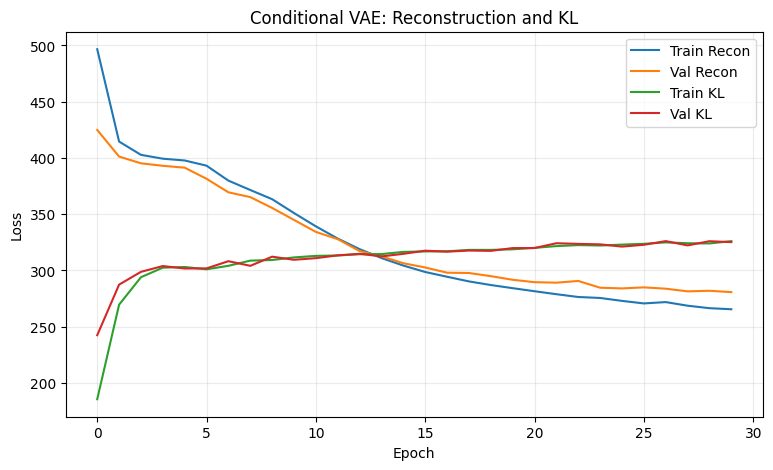

[1] style=       baroque -> generated_midi_vae/vae_style_baroque_1.mid
[2] style=     classical -> generated_midi_vae/vae_style_classical_2.mid
[3] style= impressionist -> generated_midi_vae/vae_style_impressionist_3.mid
[4] style=        modern -> generated_midi_vae/vae_style_modern_4.mid
[5] style=other_classical -> generated_midi_vae/vae_style_other_classical_5.mid
[6] style=      romantic -> generated_midi_vae/vae_style_romantic_6.mid
[7] style=       baroque -> generated_midi_vae/vae_style_baroque_7.mid
[8] style=     classical -> generated_midi_vae/vae_style_classical_8.mid
                   model  test_reconstruction_mse
0          Task1_LSTM_AE                 0.249658
1  Task2_Conditional_VAE                 0.250588


In [7]:
df_abs = df.copy()
df_abs["abs_midi_path"] = df_abs["midi_filename"].apply(lambda p: os.path.normpath(os.path.join(DATASET_PATH, p)))

def composer_to_style(composer_name):
    c = str(composer_name).lower()
    if any(k in c for k in ["bach", "handel", "vivaldi", "scarlatti", "pachelbel"]):
        return "baroque"
    if any(k in c for k in ["mozart", "haydn", "beethoven", "clementi"]):
        return "classical"
    if any(k in c for k in ["chopin", "liszt", "schumann", "schubert", "brahms", "tchaikovsky", "rachmaninoff", "grieg", "dvorak"]):
        return "romantic"
    if any(k in c for k in ["debussy", "ravel", "satie"]):
        return "impressionist"
    if any(k in c for k in ["stravinsky", "prokofiev", "shostakovich", "bartok", "strauss", "ginastera"]):
        return "modern"
    if any(k in c for k in ["glass", "adams", "kapustin", "einaudi"]):
        return "contemporary"
    return "other_classical"

path_to_style = {}
for _, row in df_abs.iterrows():
    abs_path = os.path.normpath(row["abs_midi_path"])
    style = composer_to_style(row.get("canonical_composer", ""))
    path_to_style[abs_path] = style

def paths_to_style_onehot(paths):
    styles = [path_to_style.get(os.path.normpath(p), "other_classical") for p in paths]
    unique = sorted(set(path_to_style.values()) | {"other_classical"})
    idx = {s: i for i, s in enumerate(unique)}
    labels = np.array([idx[s] for s in styles], dtype=np.int32)
    onehot = np.eye(len(unique), dtype=np.float32)[labels]
    return onehot, labels, unique

G_train, _, style_names = paths_to_style_onehot(train_paths)
G_val, _, _ = paths_to_style_onehot(val_paths)
G_test, _, _ = paths_to_style_onehot(test_paths)

vae_train_dataset = tf.data.Dataset.from_tensor_slices(((X_train, G_train), X_train)).shuffle(len(X_train)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
vae_val_dataset = tf.data.Dataset.from_tensor_slices(((X_val, G_val), X_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

BETA = 0.002
VAE_LATENT_DIM = 64
VAE_EPOCHS = 30

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

seq_in = layers.Input(shape=(TIMESTEPS, N_FEATURES), name="vae_seq_in")
style_in = layers.Input(shape=(len(style_names),), name="vae_style_in")
style_rep = layers.RepeatVector(TIMESTEPS)(style_in)
enc_input = layers.Concatenate(axis=-1)([seq_in, style_rep])
enc_h = layers.LSTM(LSTM_UNITS, name="vae_enc_lstm")(enc_input)
z_mean = layers.Dense(VAE_LATENT_DIM, name="z_mean")(enc_h)
z_log_var = layers.Dense(VAE_LATENT_DIM, name="z_log_var")(enc_h)
z = Sampling(name="z_sample")([z_mean, z_log_var])
vae_encoder = Model([seq_in, style_in], [z_mean, z_log_var, z], name="vae_encoder")

z_in = layers.Input(shape=(VAE_LATENT_DIM,), name="vae_z_in")
style_dec_in = layers.Input(shape=(len(style_names),), name="vae_style_dec_in")
dec_seed = layers.Concatenate()([z_in, style_dec_in])
dec_rep = layers.RepeatVector(TIMESTEPS)(dec_seed)
dec_h = layers.LSTM(LSTM_UNITS, return_sequences=True, name="vae_dec_lstm")(dec_rep)
dec_out = layers.TimeDistributed(layers.Dense(N_FEATURES), name="vae_reconstruction_logits")(dec_h)
vae_decoder = Model([z_in, style_dec_in], dec_out, name="vae_decoder")

class ConditionalVAE(Model):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        (x, g), y = data
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder([x, g], training=True)
            y_pred_logits = self.decoder([z, g], training=True)
            recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(y - y_pred_logits), axis=(1, 2)))
            kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
            total_loss = recon_loss + self.beta * kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        (x, g), y = data
        z_mean, z_log_var, z = self.encoder([x, g], training=False)
        y_pred_logits = self.decoder([z, g], training=False)
        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(y - y_pred_logits), axis=(1, 2)))
        kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
        total_loss = recon_loss + self.beta * kl_loss
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

vae = ConditionalVAE(vae_encoder, vae_decoder, beta=BETA, name="conditional_vae")
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE))
vae_es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)
vae_history = vae.fit(
    vae_train_dataset,
    validation_data=vae_val_dataset,
    epochs=VAE_EPOCHS,
    callbacks=[vae_es],
    verbose=1,
    )

plt.figure(figsize=(9, 5))
plt.plot(vae_history.history["recon_loss"], label="Train Recon")
plt.plot(vae_history.history["val_recon_loss"], label="Val Recon")
plt.plot(vae_history.history["kl_loss"], label="Train KL")
plt.plot(vae_history.history["val_kl_loss"], label="Val KL")
plt.title("Conditional VAE: Reconstruction and KL")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

OUTPUT_DIR_VAE = "generated_midi_vae"
os.makedirs(OUTPUT_DIR_VAE, exist_ok=True)

n_gen = 8
style_cycle = [style_names[i % len(style_names)] for i in range(n_gen)]
style_to_idx = {s: i for i, s in enumerate(style_names)}
for i, style_name in enumerate(style_cycle, start=1):
    g = np.zeros((1, len(style_names)), dtype=np.float32)
    g[0, style_to_idx[style_name]] = 1.0
    z_sample = np.random.normal(0.0, 1.0, size=(1, VAE_LATENT_DIM)).astype(np.float32)
    logits_roll = vae_decoder.predict([z_sample, g], verbose=0)[0]
    prob_roll = tf.keras.activations.sigmoid(logits_roll).numpy()
    pm = roll_to_pretty_midi(prob_roll, fs=FS, threshold=0.35, min_note_steps=2, max_notes_per_step=10)
    out_path = os.path.join(OUTPUT_DIR_VAE, f"vae_style_{style_name}_{i}.mid")
    pm.write(out_path)
    print(f"[{i}] style={style_name:>14s} -> {out_path}")

X_test_recon_ae_logits = autoencoder.predict(X_test, verbose=0)
X_test_recon_ae = tf.keras.activations.sigmoid(X_test_recon_ae_logits).numpy()
task1_test_mse = float(np.mean((X_test - X_test_recon_ae) ** 2))
_, _, z_test = vae_encoder.predict([X_test, G_test], verbose=0)
X_test_recon_vae_logits = vae_decoder.predict([z_test, G_test], verbose=0)
X_test_recon_vae = tf.keras.activations.sigmoid(X_test_recon_vae_logits).numpy()
task2_test_mse = float(np.mean((X_test - X_test_recon_vae) ** 2))
metrics_df = pd.DataFrame([
    {"model": "Task1_LSTM_AE", "test_reconstruction_mse": task1_test_mse},
    {"model": "Task2_Conditional_VAE", "test_reconstruction_mse": task2_test_mse},
])
print(metrics_df)

## Task 3 : Transformer-Based Music Generator

Goal: train an autoregressive Transformer decoder for longer sequence generation.

Formulation:
- p(X) = product_t p(x_t | x_<t)
- Training loss: L = -sum_t log p_theta(x_t | x_<t)
- Perplexity: exp(mean token NLL)

Research note: to keep training tractable in notebook runtime, this section uses a **monophonic token abstraction** from piano-roll frames (0 = silence, 1..128 = active pitch). This is a simplification, reported explicitly for reproducibility.

Deliverables in this section:
1. Transformer decoder implementation
2. Perplexity evaluation on held-out data
3. 10 generated long-sequence MIDI files

Token dataset shapes:
Train: (250756, 64) (250756, 64)
Val  : (15752, 64) (15752, 64)
Test : (15584, 64) (15584, 64)


Model: "music_transformer_decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tokens (InputLayer) │ (None, 64)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 64, 128)   │     24,704 │ tokens[0][0]      │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 128)   │    263,808 │ token_and_positi… │
│ (MultiHeadAttentio… │                   │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 128)   │          0 │ token_and_positi… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 256)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64, 128)   │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 128)   │    263,808 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 128)   │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64, 256)   │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64, 128)   │     32,896 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 64, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 128)   │        256 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_logits        │ (None, 64, 129)   │     16,641 │ layer_normalizat… │
│ (Dense)             │                   │            │                 

 Total params: 701,825 (2.68 MB)

 Trainable params: 701,825 (2.68 MB)

...

Epoch 1/15


I0000 00:00:1778204067.128270      72 service.cc:152] XLA service 0x7ddd0c006d80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778204067.128359      72 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


  18/3919 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step - acc: 0.3220 - loss: 3.7716

I0000 00:00:1778204072.694172      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3919/3919 ━━━━━━━━━━━━━━━━━━━━ 55s 11ms/step - acc: 0.8153 - loss: 1.0385 - val_acc: 0.8289 - val_loss: 0.9070
Epoch 2/15
3919/3919 ━━━━━━━━━━━━━━━━━━━━ 38s 10ms/step - acc: 0.8253 - loss: 0.9055 - val_acc: 0.8292 - val_loss: 0.8951
Epoch 3/15
3919/3919 ━━━━━━━━━━━━━━━━━━━━ 38s 10ms/step - acc: 0.8256 - loss: 0.8892 - val_acc: 0.8293 - val_loss: 0.8891
Epoch 4/15
3919/3919 ━━━━━━━━━━━━━━━━━━━━ 38s 10ms/step - acc: 0.8259 - loss: 0.8796 - val_acc: 0.8294 - val_loss: 0.8857
Epoch 5/15
3919/3919 ━━━━━━━━━━━━━━━━━━━━ 38s 10ms/step - acc: 0.8261 - loss: 0.8732 - val_acc: 0.8293 - val_loss: 0.8838
Epoch 6/15
3919/3919 ━━━━━━━━━━━━━━━━━━━━ 38s 10ms/step - acc: 0.8263 - loss: 0.8683 - val_acc: 0.8293 - val_loss: 0.8834
Epoch 7/15
3919/3919 ━━━━━━━━━━━━━━━━━━━━ 38s 10ms/step - acc: 0.8265 - loss: 0.8645 - val_acc: 0.8292 - val_loss: 0.8829
Epoch 8/15
3919/3919 ━━━━━━━━━━━━━━━━━━━━ 38s 10ms/step - acc: 0.8266 - loss: 0.8612 - val_acc: 0.8292 - val_loss: 0.8829
Epoch 9/15
3919/3919 ━━━━━━━━━━━━━━

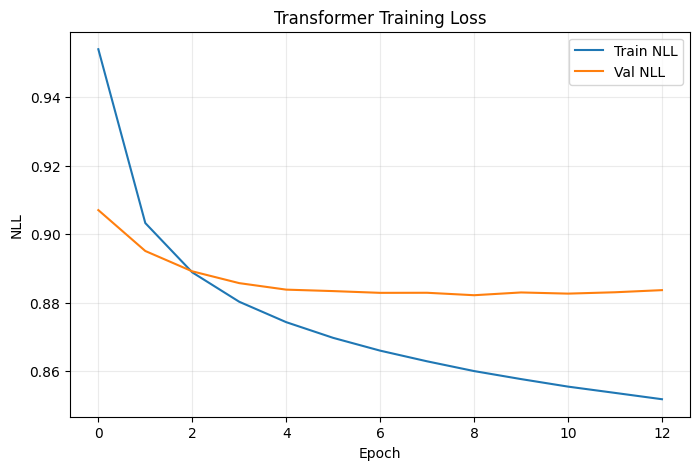

Generating 10 long compositions in: /kaggle/working/generated_midi_transformer
[1] generated_midi_transformer/transformer_long_1.mid (tokens=512)
[2] generated_midi_transformer/transformer_long_2.mid (tokens=512)
[3] generated_midi_transformer/transformer_long_3.mid (tokens=512)
[4] generated_midi_transformer/transformer_long_4.mid (tokens=512)
[5] generated_midi_transformer/transformer_long_5.mid (tokens=512)
[6] generated_midi_transformer/transformer_long_6.mid (tokens=512)
[7] generated_midi_transformer/transformer_long_7.mid (tokens=512)
[8] generated_midi_transformer/transformer_long_8.mid (tokens=512)
[9] generated_midi_transformer/transformer_long_9.mid (tokens=512)
[10] generated_midi_transformer/transformer_long_10.mid (tokens=512)

Task 3 complete. Perplexity: 2.515984317956705


In [8]:

# Task 3: Autoregressive Transformer


if 'X_train' not in globals() or 'X_val' not in globals() or 'X_test' not in globals():
    raise RuntimeError("Run Task 1 preprocessing cells first.")

# 1) Convert piano-rolls to token sequences (monophonic abstraction) 
def roll_to_token_sequence(roll, threshold=0.5):
    tokens = []
    for t in range(roll.shape[0]):
        active = np.where(roll[t] >= threshold)[0]
        if len(active) == 0:
            tokens.append(0)
        else:
            # Use the highest active pitch at each step as the token.
            tokens.append(int(active.max()) + 1)
    return np.array(tokens, dtype=np.int32)

def make_ar_dataset(X, context_len=64, stride=32):
    X_in, Y_out = [], []
    for roll in X:
        seq = roll_to_token_sequence(roll)
        inp = seq[:-1]
        tgt = seq[1:]
        if len(inp) < context_len:
            continue
        for start in range(0, len(inp) - context_len + 1, stride):
            x_win = inp[start:start + context_len]
            y_win = tgt[start:start + context_len]
            X_in.append(x_win)
            Y_out.append(y_win)
    if not X_in:
        raise RuntimeError("No training windows created for Transformer.")
    return np.array(X_in, dtype=np.int32), np.array(Y_out, dtype=np.int32)

VOCAB_SIZE = 129  # 0=silence, 1..128=pitches
CONTEXT_LEN = 64

X_tok_train, y_tok_train = make_ar_dataset(X_train, context_len=CONTEXT_LEN, stride=16)
X_tok_val, y_tok_val = make_ar_dataset(X_val, context_len=CONTEXT_LEN, stride=32)
X_tok_test, y_tok_test = make_ar_dataset(X_test, context_len=CONTEXT_LEN, stride=32)

print("Token dataset shapes:")
print("Train:", X_tok_train.shape, y_tok_train.shape)
print("Val  :", X_tok_val.shape, y_tok_val.shape)
print("Test :", X_tok_test.shape, y_tok_test.shape)

# 2) Build Transformer decoder
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)
        self.maxlen = maxlen

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        pos = self.pos_emb(positions)
        tok = self.token_emb(x)
        return tok + pos

def transformer_decoder_block(x, embed_dim, num_heads, ff_dim, dropout=0.1):
    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim, dropout=dropout
    )(x, x, use_causal_mask=True)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)

    ffn = layers.Dense(ff_dim, activation="relu")(x)
    ffn = layers.Dropout(dropout)(ffn)
    ffn = layers.Dense(embed_dim)(ffn)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn)
    return x

EMBED_DIM = 128
NUM_HEADS = 4
FF_DIM = 256
TR_EPOCHS = 15

tok_in = layers.Input(shape=(CONTEXT_LEN,), dtype=tf.int32, name="tokens")
x = TokenAndPositionEmbedding(CONTEXT_LEN, VOCAB_SIZE, EMBED_DIM)(tok_in)
x = transformer_decoder_block(x, EMBED_DIM, NUM_HEADS, FF_DIM, dropout=0.1)
x = transformer_decoder_block(x, EMBED_DIM, NUM_HEADS, FF_DIM, dropout=0.1)
logits = layers.Dense(VOCAB_SIZE, name="token_logits")(x)

transformer = Model(tok_in, logits, name="music_transformer_decoder")
transformer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="acc")],
)
transformer.summary()

tr_es = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1,
)

tr_history = transformer.fit(
    X_tok_train,
    y_tok_train,
    validation_data=(X_tok_val, y_tok_val),
    epochs=TR_EPOCHS,
    batch_size=64,
    callbacks=[tr_es],
    verbose=1,
)

# 3) Perplexity evaluation
test_loss, test_acc = transformer.evaluate(X_tok_test, y_tok_test, verbose=0)
perplexity = float(np.exp(test_loss))

print("\n=== Transformer Evaluation ===")
print(f"Test token NLL: {test_loss:.6f}")
print(f"Test token accuracy: {test_acc:.6f}")
print(f"Perplexity: {perplexity:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(tr_history.history["loss"], label="Train NLL")
plt.plot(tr_history.history["val_loss"], label="Val NLL")
plt.title("Transformer Training Loss")
plt.xlabel("Epoch")
plt.ylabel("NLL")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# 4) Autoregressive generation (10 long sequences)
OUTPUT_DIR_TR = "generated_midi_transformer"
os.makedirs(OUTPUT_DIR_TR, exist_ok=True)

def sample_next_token(logits_vec, temperature=1.0, top_k=12):
    logits_vec = logits_vec.astype(np.float64) / max(temperature, 1e-6)
    if top_k is not None and top_k < len(logits_vec):
        top_idx = np.argpartition(logits_vec, -top_k)[-top_k:]
        top_logits = logits_vec[top_idx]
        probs = np.exp(top_logits - np.max(top_logits))
        probs = probs / np.sum(probs)
        return int(np.random.choice(top_idx, p=probs))
    probs = np.exp(logits_vec - np.max(logits_vec))
    probs = probs / np.sum(probs)
    return int(np.random.choice(np.arange(len(logits_vec)), p=probs))

def tokens_to_pretty_midi(tokens, fs=FS):
    seconds_per_step = 1.0 / fs
    pm = pretty_midi.PrettyMIDI()
    piano = pretty_midi.Instrument(program=0, name="transformer_piano")

    t = 0
    while t < len(tokens):
        tok = int(tokens[t])
        if tok == 0:
            t += 1
            continue

        pitch = tok - 1
        start = t
        t += 1
        while t < len(tokens) and int(tokens[t]) == tok:
            t += 1
        end = t

        piano.notes.append(
            pretty_midi.Note(
                velocity=90,
                pitch=int(np.clip(pitch, 0, 127)),
                start=start * seconds_per_step,
                end=end * seconds_per_step,
            )
        )

    pm.instruments.append(piano)
    return pm

N_GENERATE = 10
GEN_STEPS = 512

print(f"Generating {N_GENERATE} long compositions in: {os.path.abspath(OUTPUT_DIR_TR)}")
for i in range(1, N_GENERATE + 1):
    seed_idx = np.random.randint(0, len(X_tok_test))
    context = list(X_tok_test[seed_idx].tolist())

    generated = context.copy()
    for _ in range(GEN_STEPS):
        x_in = np.array(generated[-CONTEXT_LEN:], dtype=np.int32)[None, :]
        pred_logits = transformer.predict(x_in, verbose=0)[0, -1]
        nxt = sample_next_token(pred_logits, temperature=1.0, top_k=12)
        generated.append(nxt)

    # Drop initial context so the saved output reflects autoregressive continuation.
    out_tokens = generated[CONTEXT_LEN:]
    pm = tokens_to_pretty_midi(out_tokens, fs=FS)
    out_path = os.path.join(OUTPUT_DIR_TR, f"transformer_long_{i}.mid")
    pm.write(out_path)
    print(f"[{i}] {out_path} (tokens={len(out_tokens)})")

print("\nTask 3 complete. Perplexity:", perplexity)